# Data loading

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. CONFIGURATION & LOADING
# ==========================================
FILENAME = '/Users/lucas/Things/doutorado/experiments/workloads/mustang_release_v1.0beta.csv'
CLUSTER_CAPACITY = 1600             # number of identical compute nodes

df = pd.read_csv(FILENAME)

# Convert columns to UTC datetime
for col in ['submit_time', 'start_time', 'end_time']:
    df[col] = pd.to_datetime(df[col], utc=True)

# Sort by submission time
df = df.sort_values(by='submit_time').reset_index(drop=True)

# Week selection

## Poisson

>>> Calculating Rolling Window Statistics (Poisson-like via binned counts)...

Top 10 most Poisson-like weeks (closest ratio to 1):
                          date  cv_ratio  mean_per_bin  total_events      dist
415  2012-12-26 00:00:00+00:00  1.058532     56.571429         396.0  0.058532
159  2012-04-14 00:00:00+00:00  1.118369     81.714286         572.0  0.118369
414  2012-12-25 00:00:00+00:00  1.131641     56.000000         392.0  0.131641
1111 2014-11-22 00:00:00+00:00  1.480751    253.428571        1774.0  0.480751
160  2012-04-15 00:00:00+00:00  1.648697     78.142857         547.0  0.648697
287  2012-08-20 00:00:00+00:00  1.758037    188.571429        1320.0  0.758037
288  2012-08-21 00:00:00+00:00  1.923200    191.142857        1338.0  0.923200
326  2012-09-28 00:00:00+00:00  1.950995    225.142857        1576.0  0.950995
1368 2015-08-06 00:00:00+00:00  1.975775   3151.285714       22059.0  0.975775
90   2012-02-05 00:00:00+00:00  2.007826     71.571429         501.0  1.007826

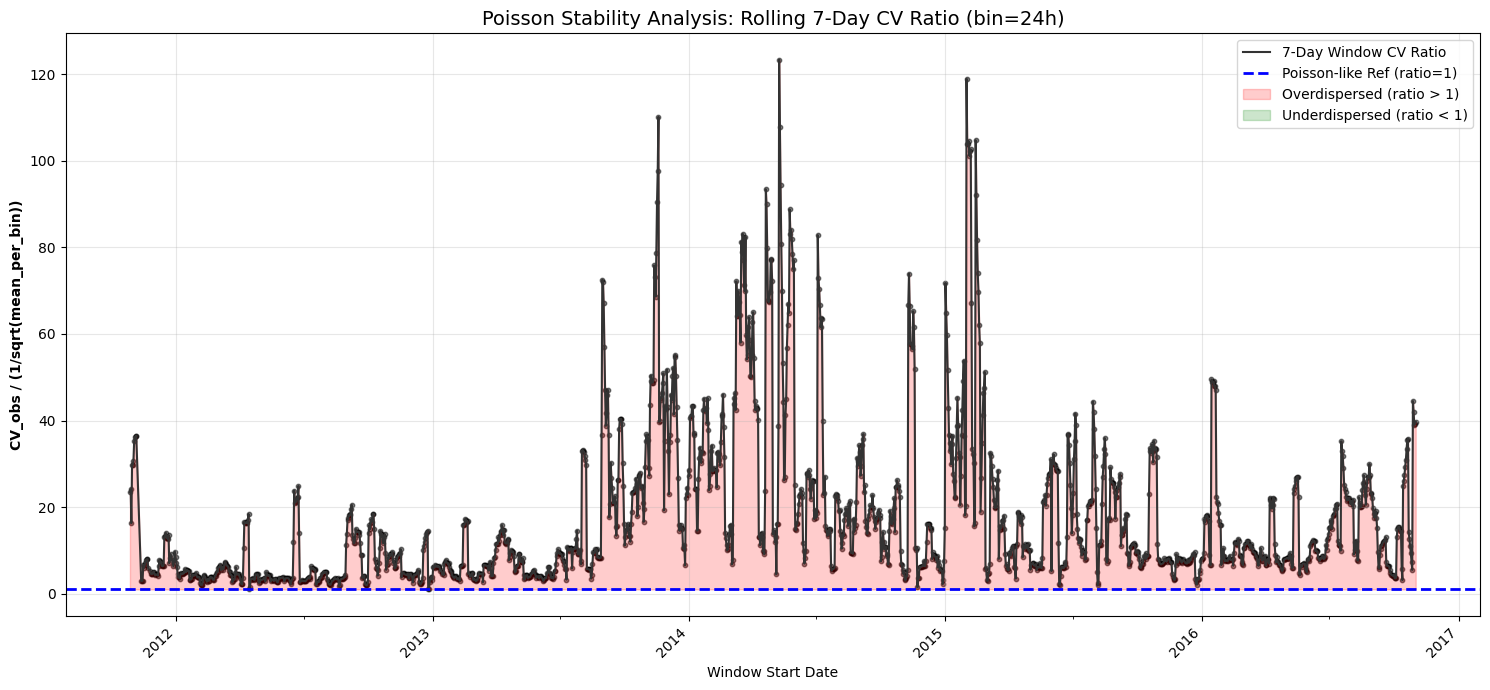

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. DATA PREPARATION
# ==========================================
print(">>> Calculating Rolling Window Statistics (Poisson-like via binned counts)...")

# Assumes df has a datetime column: df['submit_time']
df = df.sort_values("submit_time").copy()

# Bin size used to build count time series
BIN = "24h"   # try also: "15min", "1H"

# Build a binned count series (includes zeros between events)
counts = df.set_index("submit_time").resample(BIN).size().astype(float)

# Define the date range for the sliding window (full 7-day windows)
start_date = counts.index.min().floor("D")
end_date = counts.index.max().floor("D") - pd.Timedelta(days=7)
dates_to_analyze = pd.date_range(start_date, end_date, freq="D", tz=counts.index.tz)

# ==========================================
# 2. SLIDING WINDOW CALCULATION
# ==========================================
results = []

for window_start in dates_to_analyze:
    window_end = window_start + pd.Timedelta(days=7)

    # Slice binned counts strictly inside [window_start, window_end)
    window_counts = counts.loc[window_start:window_end - pd.Timedelta(microseconds=1)]

    # Use total submissions in the window as a basic minimum-data threshold
    total_events = window_counts.sum()

    if total_events > 50:
        mu = window_counts.mean()               # mean submissions per bin
        sigma = window_counts.std(ddof=0)       # std submissions per bin

        # Observed CV across bins in this week
        cv_obs = (sigma / mu) if mu > 0 else np.nan

        # Poisson expectation for binned counts: CV = 1/sqrt(mu)
        cv_pois = (1.0 / np.sqrt(mu)) if mu > 0 else np.nan

        # Poisson-likeness ratio: ~1 means close to Poisson dispersion
        cv_ratio = (cv_obs / cv_pois) if (np.isfinite(cv_obs) and np.isfinite(cv_pois) and cv_pois > 0) else np.nan

        results.append({
            "date": window_start,
            "cv_ratio": cv_ratio,
            "mean_per_bin": mu,
            "total_events": total_events
        })

df_rolling = pd.DataFrame(results).dropna()

# Optional: show best weeks (closest to Poisson-like ratio 1)
df_best = df_rolling.assign(dist=(df_rolling["cv_ratio"] - 1.0).abs()).sort_values("dist").head(10)
print("\nTop 10 most Poisson-like weeks (closest ratio to 1):")
print(df_best[["date", "cv_ratio", "mean_per_bin", "total_events", "dist"]])

# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(figsize=(15, 7))

# Plot the Rolling CV ratio line (Poisson-like ~ 1)
ax.plot(df_rolling["date"], df_rolling["cv_ratio"], color="#333333", linewidth=1.5, label="7-Day Window CV Ratio")
ax.scatter(df_rolling["date"], df_rolling["cv_ratio"], color="black", s=10, alpha=0.5)

# Reference line for Poisson-like behavior (ratio = 1)
ax.axhline(y=1, color="blue", linestyle="--", linewidth=2, label="Poisson-like Ref (ratio=1)")

# Highlight: bursty vs regular (relative to Poisson expectation)
ax.fill_between(df_rolling["date"], df_rolling["cv_ratio"], 1,
                where=(df_rolling["cv_ratio"] > 1),
                color="red", alpha=0.2, interpolate=True, label="Overdispersed (ratio > 1)")
ax.fill_between(df_rolling["date"], df_rolling["cv_ratio"], 1,
                where=(df_rolling["cv_ratio"] < 1),
                color="green", alpha=0.2, interpolate=True, label="Underdispersed (ratio < 1)")

# Formatting
span_days = (df_rolling["date"].max() - df_rolling["date"].min()).days if not df_rolling.empty else 0

if span_days >= 365 * 3:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))
elif span_days >= 365:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
else:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())

plt.xticks(rotation=45, ha="right")

ax.set_title(f"Poisson Stability Analysis: Rolling 7-Day CV Ratio (bin={BIN})", fontsize=14)
ax.set_ylabel("CV_obs / (1/sqrt(mean_per_bin))", fontweight="bold")
ax.set_xlabel("Window Start Date")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


## Global Plot (multi-year)


In [ ]:
# @title
# ==========================================
# 2. GLOBAL PLOT (MULTI-YEAR FRIENDLY)
# ==========================================
#
# This section is adapted for long traces (e.g., 2011–2016). The key changes are:
# - coarser aggregation for submissions (weekly by default)
# - efficient utilization time series (event-based), avoiding O(N * T) filtering loops
# - adaptive date ticks/labels

# ---- knobs you can tune ----
GLOBAL_SUBMIT_BIN = "7D"   # submissions aggregation (try: "1D", "14D")
GLOBAL_LOAD_FREQ  = "1D"   # utilization sampling grid (try: "12H", "6H", "1D")

# 1) Submissions (bars)
submit_counts = df.set_index("submit_time").resample(GLOBAL_SUBMIT_BIN).size()

# 2) Utilization / node occupancy (line) - robust event-based cumulative sum
# We build a step function of node usage:
#   +node_count at start_time
#   -node_count at end_time
# Important: deltas are NOT forward-filled; missing timestamps mean delta=0.

START_COL = "start_time"
END_COL   = "end_time"
SIZE_COL  = "node_count"

# Keep only valid rows
tmp = df[[START_COL, END_COL, SIZE_COL]].dropna().copy()
tmp = tmp[tmp[SIZE_COL] > 0]

# Drop obviously broken records (end before start)
tmp = tmp[tmp[END_COL] >= tmp[START_COL]]

# Aggregate simultaneous starts/ends by timestamp (handles duplicate labels)
starts = tmp.groupby(START_COL)[SIZE_COL].sum()
ends   = -tmp.groupby(END_COL)[SIZE_COL].sum()

# Delta events over time (unique index after groupby)
events_delta = pd.concat([starts, ends]).groupby(level=0).sum().sort_index()

# Regular grid for plotting
tmin = events_delta.index.min().floor("D")
tmax = events_delta.index.max().ceil("D")

# If your timestamps are timezone-aware, preserve tz; otherwise don't pass tz=
tzinfo = getattr(events_delta.index, "tz", None)
if tzinfo is None:
    time_range_global = pd.date_range(tmin, tmax, freq=GLOBAL_LOAD_FREQ)
else:
    time_range_global = pd.date_range(tmin, tmax, freq=GLOBAL_LOAD_FREQ, tz=tzinfo)

# Align deltas to the union grid: missing timestamps => delta=0
delta_union = events_delta.reindex(events_delta.index.union(time_range_global)).fillna(0).sort_index()

# Occupancy level is the cumulative sum of deltas
occupancy = delta_union.cumsum()

# Sample occupancy on the grid; forward-fill levels between grid points
occupancy_aligned = occupancy.reindex(time_range_global).ffill().fillna(0.0)

# Optional safety: keep occupancy non-negative (helps if the trace has small inconsistencies)
occupancy_aligned = occupancy_aligned.clip(lower=0)

df_load_global = pd.DataFrame({"time": time_range_global, "nodes": occupancy_aligned.values})

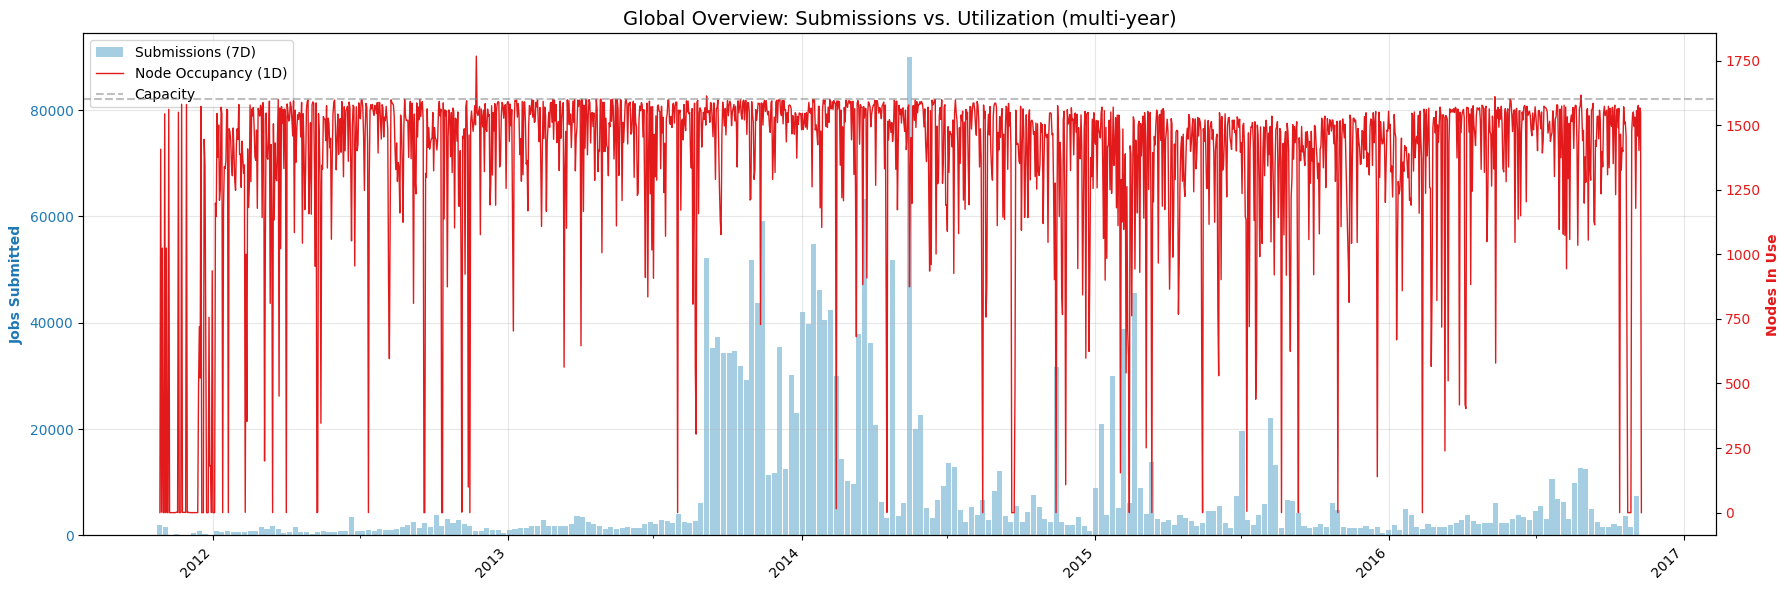

In [ ]:
# @title
# Plotting (adaptive ticks for long horizons)

fig, ax1 = plt.subplots(figsize=(18, 6))
ax1.set_title("Global Overview: Submissions vs. Utilization (multi-year)", fontsize=14)

# --- Axis 1: Submissions (Bars) ---
# Matplotlib date bar width is in "days"
try:
    bin_seconds = pd.to_timedelta(GLOBAL_SUBMIT_BIN).total_seconds()
    bar_width_days = max(1.0, bin_seconds / 86400.0) * 0.90
except ValueError:
    # Fallback for non-fixed frequencies
    bar_width_days = 6.0  # a bit narrower than the bin

ax1.bar(submit_counts.index, submit_counts.values, width=bar_width_days, color="#a6cee3", label=f"Submissions ({GLOBAL_SUBMIT_BIN})")
ax1.set_ylabel("Jobs Submitted", color="#1f78b4", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1f78b4")

# --- Axis 2: Utilization (Line) ---
ax2 = ax1.twinx()
ax2.plot(df_load_global["time"], df_load_global["nodes"], color="#e31a1c", linewidth=1, label=f"Node Occupancy ({GLOBAL_LOAD_FREQ})")
ax2.set_ylabel("Nodes In Use", color="#e31a1c", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#e31a1c")
ax2.axhline(y=CLUSTER_CAPACITY, color="gray", linestyle="--", alpha=0.5, label="Capacity")

# --- Adaptive X axis formatting ---
span_days = (df_load_global["time"].max() - df_load_global["time"].min()).days

if span_days >= 365 * 3:
    major_locator = mdates.YearLocator()
    major_fmt = mdates.DateFormatter("%Y")
    minor_locator = mdates.MonthLocator(interval=6)
elif span_days >= 365:
    major_locator = mdates.MonthLocator(interval=3)
    major_fmt = mdates.DateFormatter("%Y-%m")
    minor_locator = mdates.MonthLocator()
else:
    major_locator = mdates.DayLocator(interval=7)
    major_fmt = mdates.DateFormatter("%d-%m")
    minor_locator = mdates.DayLocator()

ax1.xaxis.set_major_locator(major_locator)
ax1.xaxis.set_major_formatter(major_fmt)
ax1.xaxis.set_minor_locator(minor_locator)

plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.grid(True, alpha=0.3)

# Legend: merge both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Weeks that have larger jobs

In [ ]:
import pandas as pd
import numpy as np

def rolling_7d_large_share_with_poisson(
    df: pd.DataFrame,
    *,
    time_col: str = "submit_time",
    size_col: str = "node_count",
    # Define "large"
    large_node_threshold: int | None = None,   # e.g., 256
    large_percentile: float | None = 0.95,     # e.g., top 5%
    # Window and binning
    window_days: int = 7,
    poisson_bin: str = "24h",                   # choose same bin you used before: "5min", "15min", "1H", etc.
    min_bins_in_window: int = 7,              # require at least this many bins to report poisson metrics
    # Output
    newest_first: bool = True,
) -> pd.DataFrame:
    """
    For each day D, compute metrics over the forward window [D, D+window_days):
      - total_jobs_7d, large_jobs_7d, large_pct_7d
      - poisson_dispersion_7d = var(counts_per_bin) / mean(counts_per_bin)  (Poisson => ~1)
      - poisson_distance_7d   = abs(poisson_dispersion_7d - 1)

    Notes:
      - "week" here means a rolling 7-day window starting at each day.
      - Poisson metric is based on submission counts binned by `poisson_bin`.
    """
    x = df[[time_col, size_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x[size_col] = pd.to_numeric(x[size_col], errors="coerce")
    x = x.dropna(subset=[time_col, size_col])
    x = x[x[size_col] > 0].sort_values(time_col)

    # Timezone awareness (preserve tz if present)
    tz = x[time_col].dt.tz

    # --- decide "large" cutoff ---
    if large_node_threshold is not None:
        cutoff = float(large_node_threshold)
    else:
        if large_percentile is None:
            large_percentile = 0.95
        cutoff = float(x[size_col].quantile(large_percentile))

    x["is_large"] = (x[size_col] >= cutoff).astype(int)

    # --- daily counts (for large-job share) ---
    x["day"] = x[time_col].dt.floor("D")
    daily = x.groupby("day").agg(
        total_jobs=("is_large", "size"),
        large_jobs=("is_large", "sum"),
    ).sort_index()

    # Full day index across the trace
    day_index = pd.date_range(
        daily.index.min(),
        daily.index.max(),
        freq="1D",
        tz=tz
    )

    daily = daily.reindex(day_index, fill_value=0)

    # Forward-looking window [D, D+7d): do backward rolling on reversed series
    daily_rev = daily.iloc[::-1]
    win = f"{window_days}D"

    total_7d = daily_rev["total_jobs"].rolling(window=win, min_periods=1).sum().iloc[::-1]
    large_7d = daily_rev["large_jobs"].rolling(window=win, min_periods=1).sum().iloc[::-1]

    large_pct_7d = np.where(total_7d.values > 0, 100.0 * large_7d.values / total_7d.values, 0.0)

    # --- Poisson metric (from binned submission counts) ---
    # Build a complete bin series (including zeros) so mean/var are correct.
    # Bin counts over entire trace
    binned = x.set_index(time_col).resample(poisson_bin).size().sort_index()

    if binned.empty:
        # If no data, return only the large-job columns
        out = pd.DataFrame({
            "day_start": day_index,
            "total_jobs_7d": total_7d.values,
            "large_jobs_7d": large_7d.values,
            "large_pct_7d": large_pct_7d,
            "poisson_mean_bin_7d": np.nan,
            "poisson_var_bin_7d": np.nan,
            "poisson_dispersion_7d": np.nan,
            "poisson_distance_7d": np.nan,
            "poisson_bins_7d": 0,
            "large_cutoff_nodes": cutoff,
        })
        return out.sort_values("day_start", ascending=not newest_first).reset_index(drop=True)

    # Make sure zeros are included across full bin range
    bin_index = pd.date_range(
        binned.index.min(),
        binned.index.max(),
        freq=poisson_bin,
        tz=getattr(binned.index, "tz", None),
    )
    binned = binned.reindex(bin_index, fill_value=0).astype(float)

    # Forward-looking rolling mean/var over 7D:
    # reverse time series, do backward-looking rolling, reverse back.
    binned_rev = binned.iloc[::-1]

    # rolling stats
    mean_rev = binned_rev.rolling(window=win, min_periods=1).mean()
    mean2_rev = (binned_rev ** 2).rolling(window=win, min_periods=1).mean()
    var_rev = mean2_rev - (mean_rev ** 2)

    # number of bins in each rolling window (for min_bins filtering)
    bins_rev = binned_rev.rolling(window=win, min_periods=1).count()

    mean_fwd = mean_rev.iloc[::-1]
    var_fwd = var_rev.iloc[::-1]
    bins_fwd = bins_rev.iloc[::-1]

    # Dispersion = var / mean, undefined when mean == 0
    dispersion = var_fwd / mean_fwd.replace(0, np.nan)
    distance = (dispersion - 1.0).abs()

    # Align poisson metrics to each day_start (D)
    # (Assumes day_start aligns with bin boundaries; true for common bins like 5min/15min/1H)
    mean_on_days = mean_fwd.reindex(day_index)
    var_on_days = var_fwd.reindex(day_index)
    disp_on_days = dispersion.reindex(day_index)
    dist_on_days = distance.reindex(day_index)
    bins_on_days = bins_fwd.reindex(day_index).fillna(0).astype(int)

    # Apply min bin requirement (optional)
    mask_ok = bins_on_days >= int(min_bins_in_window)
    mean_on_days = mean_on_days.where(mask_ok, np.nan)
    var_on_days = var_on_days.where(mask_ok, np.nan)
    disp_on_days = disp_on_days.where(mask_ok, np.nan)
    dist_on_days = dist_on_days.where(mask_ok, np.nan)

    # --- output table ---
    out = pd.DataFrame({
        "day_start": day_index,
        "total_jobs_7d": total_7d.values,
        "large_jobs_7d": large_7d.values,
        "large_pct_7d": large_pct_7d,
        "poisson_mean_bin_7d": mean_on_days.values,
        "poisson_var_bin_7d": var_on_days.values,
        "poisson_dispersion_7d": disp_on_days.values,
        "poisson_distance_7d": dist_on_days.values,
        "poisson_bins_7d": bins_on_days.values,
        "large_cutoff_nodes": cutoff,
    })

    out = out.sort_values("day_start", ascending=not newest_first).reset_index(drop=True)
    return out

table = rolling_7d_large_share_with_poisson(df, large_node_threshold=120)  # or large_node_threshold=256
top20 = (
    table[(table["total_jobs_7d"] >= 500) & (table["poisson_distance_7d"] <= 5)]
    .sort_values("large_pct_7d", ascending=False)
    .head(40)
)
display(top20[[
    "day_start",
    "large_pct_7d","large_jobs_7d","total_jobs_7d",
    "poisson_dispersion_7d","poisson_distance_7d","poisson_mean_bin_7d","poisson_var_bin_7d"
]])


,day_start,large_pct_7d,large_jobs_7d,total_jobs_7d,poisson_dispersion_7d,poisson_distance_7d,poisson_mean_bin_7d,poisson_var_bin_7d
1736,2012-02-07 00:00:00+00:00,54.633205,283.0,518.0,4.289575,3.289575,74.000000,317.428571
1738,2012-02-05 00:00:00+00:00,54.291417,272.0,501.0,4.031366,3.031366,71.571429,288.530612
1668,2012-04-15 00:00:00+00:00,27.970750,153.0,547.0,2.718203,1.718203,78.142857,212.408163
1669,2012-04-14 00:00:00+00:00,27.670753,158.0,571.0,1.270953,0.270953,81.571429,103.673469
1679,2012-04-04 00:00:00+00:00,26.527051,152.0,573.0,4.608826,3.608826,81.857143,377.265306
1681,2012-04-02 00:00:00+00:00,25.349650,145.0,572.0,5.275225,4.275225,81.714286,431.061224
1680,2012-04-03 00:00:00+00:00,24.162257,137.0,567.0,4.984127,3.984127,81.000000,403.714286
681,2014-12-28 00:00:00+00:00,16.759003,121.0,722.0,4.951326,3.951326,103.142857,510.693878
1426,2012-12-13 00:00:00+00:00,14.825871,149.0,1005.0,5.211656,4.211656,143.571429,748.244898
1424,2012-12-15 00:00:00+00:00,14.201763,145.0,1021.0,5.687421,4.687421,145.857143,829.551020


## Weeks that have smaller jobs

In [ ]:
import pandas as pd
import numpy as np

def rolling_7d_small_share_with_poisson(
    df: pd.DataFrame,
    *,
    time_col: str = "submit_time",
    size_col: str = "node_count",
    # Define "small"
    small_node_threshold: int | None = None,   # e.g., 4  (<= 4 nodes)
    small_percentile: float | None = 0.10,     # e.g., bottom 10%
    # Window and binning
    window_days: int = 7,
    poisson_bin: str = "24h",
    min_bins_in_window: int = 7,
    newest_first: bool = True,
) -> pd.DataFrame:
    """
    For each day D, compute metrics over the forward window [D, D+window_days):
      - total_jobs_7d, small_jobs_7d, small_pct_7d
      - poisson_dispersion_7d = var(counts_per_bin) / mean(counts_per_bin)  (Poisson => ~1)
      - poisson_distance_7d   = abs(poisson_dispersion_7d - 1)
    """
    x = df[[time_col, size_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x[size_col] = pd.to_numeric(x[size_col], errors="coerce")
    x = x.dropna(subset=[time_col, size_col])
    x = x[x[size_col] > 0].sort_values(time_col)

    tz = x[time_col].dt.tz

    # --- decide "small" cutoff ---
    if small_node_threshold is not None:
        cutoff = float(small_node_threshold)
    else:
        if small_percentile is None:
            small_percentile = 0.10
        cutoff = float(x[size_col].quantile(small_percentile))

    x["is_small"] = (x[size_col] <= cutoff).astype(int)

    # --- daily counts (for small-job share) ---
    x["day"] = x[time_col].dt.floor("D")
    daily = x.groupby("day").agg(
        total_jobs=("is_small", "size"),
        small_jobs=("is_small", "sum"),
    ).sort_index()

    day_index = pd.date_range(daily.index.min(), daily.index.max(), freq="1D", tz=tz)
    daily = daily.reindex(day_index, fill_value=0)

    # Forward-looking 7D window via reverse-time rolling
    win = f"{window_days}D"
    daily_rev = daily.iloc[::-1]

    total_7d = daily_rev["total_jobs"].rolling(window=win, min_periods=1).sum().iloc[::-1]
    small_7d = daily_rev["small_jobs"].rolling(window=win, min_periods=1).sum().iloc[::-1]
    small_pct_7d = np.where(total_7d.values > 0, 100.0 * small_7d.values / total_7d.values, 0.0)

    # --- Poisson metric from binned submission counts (include zeros) ---
    binned = x.set_index(time_col).resample(poisson_bin).size().sort_index()

    if binned.empty:
        out = pd.DataFrame({
            "day_start": day_index,
            "total_jobs_7d": total_7d.values,
            "small_jobs_7d": small_7d.values,
            "small_pct_7d": small_pct_7d,
            "poisson_mean_bin_7d": np.nan,
            "poisson_var_bin_7d": np.nan,
            "poisson_dispersion_7d": np.nan,
            "poisson_distance_7d": np.nan,
            "poisson_bins_7d": 0,
            "small_cutoff_nodes": cutoff,
        })
        return out.sort_values("day_start", ascending=not newest_first).reset_index(drop=True)

    bin_index = pd.date_range(
        binned.index.min(),
        binned.index.max(),
        freq=poisson_bin,
        tz=getattr(binned.index, "tz", None),
    )
    binned = binned.reindex(bin_index, fill_value=0).astype(float)

    # Auto-cap min_bins_in_window to what is possible in a 7D window for this bin size
    max_bins_possible = int(pd.Timedelta(days=window_days) / pd.to_timedelta(poisson_bin))
    min_bins_in_window = min(int(min_bins_in_window), max_bins_possible)

    binned_rev = binned.iloc[::-1]
    mean_rev = binned_rev.rolling(window=win, min_periods=1).mean()
    mean2_rev = (binned_rev ** 2).rolling(window=win, min_periods=1).mean()
    var_rev = mean2_rev - (mean_rev ** 2)
    bins_rev = binned_rev.rolling(window=win, min_periods=1).count()

    mean_fwd = mean_rev.iloc[::-1]
    var_fwd = var_rev.iloc[::-1]
    bins_fwd = bins_rev.iloc[::-1]

    dispersion = var_fwd / mean_fwd.replace(0, np.nan)
    distance = (dispersion - 1.0).abs()

    mean_on_days = mean_fwd.reindex(day_index)
    var_on_days = var_fwd.reindex(day_index)
    disp_on_days = dispersion.reindex(day_index)
    dist_on_days = distance.reindex(day_index)
    bins_on_days = bins_fwd.reindex(day_index).fillna(0).astype(int)

    mask_ok = bins_on_days >= int(min_bins_in_window)
    mean_on_days = mean_on_days.where(mask_ok, np.nan)
    var_on_days = var_on_days.where(mask_ok, np.nan)
    disp_on_days = disp_on_days.where(mask_ok, np.nan)
    dist_on_days = dist_on_days.where(mask_ok, np.nan)

    out = pd.DataFrame({
        "day_start": day_index,
        "total_jobs_7d": total_7d.values,
        "small_jobs_7d": small_7d.values,
        "small_pct_7d": small_pct_7d,
        "poisson_mean_bin_7d": mean_on_days.values,
        "poisson_var_bin_7d": var_on_days.values,
        "poisson_dispersion_7d": disp_on_days.values,
        "poisson_distance_7d": dist_on_days.values,
        "poisson_bins_7d": bins_on_days.values,
        "small_cutoff_nodes": cutoff,
    })

    out = out.sort_values("day_start", ascending=not newest_first).reset_index(drop=True)
    return out


table_small = rolling_7d_small_share_with_poisson(
    df,
    small_node_threshold=10,
)

top40_small = (
    table_small[(table_small["total_jobs_7d"] >= 200)  & (table_small["poisson_distance_7d"] <= 5.5)]      # optional
    .sort_values("small_pct_7d", ascending=False)
    .head(40)
)

display(top40_small[[
    "day_start",
    "small_pct_7d","small_jobs_7d","total_jobs_7d",
    "poisson_dispersion_7d","poisson_distance_7d"
]])


,day_start,small_pct_7d,small_jobs_7d,total_jobs_7d,poisson_dispersion_7d,poisson_distance_7d
460,2015-08-06 00:00:00+00:00,96.920495,21370.0,22049.0,3.848286,2.848286
459,2015-08-07 00:00:00+00:00,96.507766,21500.0,22278.0,6.487194,5.487194
1556,2012-08-05 00:00:00+00:00,74.572650,698.0,936.0,5.501526,4.501526
1541,2012-08-20 00:00:00+00:00,73.889322,948.0,1283.0,2.305089,1.305089
1540,2012-08-21 00:00:00+00:00,73.538705,931.0,1266.0,1.948544,0.948544
1555,2012-08-06 00:00:00+00:00,72.670157,694.0,955.0,4.653104,3.653104
1531,2012-08-30 00:00:00+00:00,72.447326,894.0,1234.0,5.771012,4.771012
1554,2012-08-07 00:00:00+00:00,72.250771,703.0,973.0,4.207605,3.207605
1503,2012-09-27 00:00:00+00:00,71.139241,1124.0,1580.0,3.845208,2.845208
1505,2012-09-25 00:00:00+00:00,70.545694,1073.0,1521.0,2.826712,1.826712


## Week Analysis (zoomed)


In [ ]:
# ==========================================
# CONFIGURATION (WEEK ZOOM)
# ==========================================
# Pick a week to zoom into. If you leave AUTO_PICK_WEEK=True, we choose the most
# Poisson-like week from the rolling analysis above (df_best).
AUTO_PICK_WEEK = False
ANALYSIS_START_DATE = "2012-12-13"  # used only if AUTO_PICK_WEEK=False

DELTA_TIME = 7        # days (keep 7-day window)
BIN_SIZE = "30min"       # stacked-bar granularity for the zoomed week

LIMIT_SMALL = 10
LIMIT_MEDIUM = 119


In [ ]:
# @title
# Define analysis window
if AUTO_PICK_WEEK and "df_best" in globals() and not df_best.empty:
    start_date = pd.to_datetime(df_best.iloc[0]["date"])
    # Ensure tz-aware UTC for consistent slicing
    start_date = start_date.tz_convert("UTC") if start_date.tzinfo is not None else start_date.tz_localize("UTC")
else:
    start_date = pd.to_datetime(ANALYSIS_START_DATE).tz_localize("UTC")

end_date = start_date + pd.Timedelta(days=DELTA_TIME)

print(f"Generating stacked chart for: {start_date.date()} to {end_date.date()}  (BIN_SIZE={BIN_SIZE})")

# ==========================================
# 1. DATA PREPARATION: JOB CLASSIFICATION
# ==========================================
# Filter jobs SUBMITTED within the window
mask_sub = (df['submit_time'] >= start_date) & (df['submit_time'] < end_date)
df_sub = df.loc[mask_sub].copy()

# Create size-based categories
conditions = [
    (df_sub['node_count'] <= LIMIT_SMALL),
    (df_sub['node_count'] > LIMIT_SMALL) & (df_sub['node_count'] <= LIMIT_MEDIUM),
    (df_sub['node_count'] > LIMIT_MEDIUM)
]
choices = ['1. Small', '2. Medium', '3. Large']
df_sub['category'] = np.select(conditions, choices, default='Unknown')

# Group by Time (BIN_SIZE) and Category
# 'unstack' transforms categories into columns for easy plotting
df_stacked = df_sub.set_index('submit_time').groupby(
    [pd.Grouper(freq=BIN_SIZE), 'category']
).size().unstack(fill_value=0)

# Ensure all columns exist (even if no jobs of that type were submitted)
for col in choices:
    if col not in df_stacked.columns:
        df_stacked[col] = 0

# ==========================================
# 2. DATA PREPARATION: REAL UTILIZATION (GREEN LINE)
# ==========================================
# Filter jobs RUNNING within the window
mask_run = (df['start_time'] < end_date) & (df['end_time'] > start_date)
df_run = df.loc[mask_run].copy()

# Calculate Initial Load (Jobs started before window but still running)
initial_load = df_run[df_run['start_time'] < start_date]['node_count'].sum()

# Calculate Load Changes (Events)
eventos_delta = []
for _, row in df_run.iterrows():
    if row['start_time'] >= start_date:
        eventos_delta.append((row['start_time'], row['node_count']))
    if row['end_time'] <= end_date:
        eventos_delta.append((row['end_time'], -row['node_count']))

# Create DataFrame and sort events
df_deltas = pd.DataFrame(eventos_delta, columns=['time', 'change']).sort_values(['time', 'change'])

# Apply cumulative sum starting from initial load
df_deltas['nodes_in_use'] = df_deltas['change'].cumsum() + initial_load

# Add Anchor Points (Start and End) for plot continuity
final_val = df_deltas['nodes_in_use'].iloc[-1] if not df_deltas.empty else initial_load
df_final_plot = pd.concat([
    pd.DataFrame({'time': [start_date], 'nodes_in_use': [initial_load]}),
    df_deltas,
    pd.DataFrame({'time': [end_date], 'nodes_in_use': [final_val]})
]).sort_values('time')



# @title
# ==========================================
# 3. PLOTTING (STACKED BARS + LINE)
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 7))

# --- AXIS 1: STACKED BARS ---
colors = {
    "1. Small":  "#a6cee3",  # light blue
    "2. Medium": "#1f78b4",  # dark blue
    "3. Large":  "#33a02c",  # green (highlight)
}

# Bar width derived from BIN_SIZE (matplotlib expects width in days)
bar_width = pd.to_timedelta(BIN_SIZE).total_seconds() / 86400.0 * 0.90

# Variable to control the stacking "base"
bottom_accumulator = np.zeros(len(df_stacked))

for category in choices:
    values = df_stacked[category].values
    ax1.bar(
        df_stacked.index,
        values,
        width=bar_width,
        bottom=bottom_accumulator,
        color=colors[category],
        alpha=0.7,
        align="edge",
        label=f"{category} Jobs",
    )
    bottom_accumulator += values

ax1.set_title(f"Workload Composition & Utilization: {start_date.date()} to {end_date.date()} - large jobs: (node_count >= 120); small jobs: (node_count <= 10)", fontsize=14)
ax1.set_ylabel(f"Submissions (count per {BIN_SIZE})", color="#1f78b4", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1f78b4")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b %Hh"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# --- AXIS 2: REAL UTILIZATION ---
ax2 = ax1.twinx()
ax2.step(
    df_final_plot["time"],
    df_final_plot["nodes_in_use"],
    where="post",
    color="#e31a1c",
    linewidth=0.6,
    label="Total Utilization (Nodes)",
)
ax2.set_ylabel("Nodes In Use", color="#e31a1c", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#e31a1c")
ax2.set_ylim(bottom=0)
ax2.axhline(y=CLUSTER_CAPACITY, color="gray", linestyle="--", alpha=0.5, label="Node Capacity")

# --- UNIFIED LEGEND ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", ncol=2, frameon=True)

ax1.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# Download selected weeks data

In [ ]:
# @title
# Export weekly artifacts (ONLY 3 files per week folder):
#   1) workload_week.png          (weekly workload plot)
#   2) week_fraction.csv          (RAW rows: submit_time within the week)
#   3) workload_batsim.json       (Batsim workload JSON for the week)
#
# Assumes Mustang-style columns:
#   submit_time, start_time, end_time, node_count, wallclock_limit
#
# NOTE: wallclock_limit is parsed as a timedelta-like value (e.g., "0 days 08:00:00.000000000")
# and converted to seconds for Batsim.

from __future__ import annotations

import json
from pathlib import Path
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _ensure_datetime(df: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
    """Ensure the given columns are pandas datetime."""
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_datetime(out[c], errors="coerce")
    return out


def _build_events_delta(
    df: pd.DataFrame,
    start_col: str = "start_time",
    end_col: str = "end_time",
    size_col: str = "node_count",
) -> pd.Series:
    """
    Build delta events over the whole trace:
      +size_col at start_col
      -size_col at end_col
    Returns a Series indexed by timestamp (unique) with delta values.
    """
    tmp = df[[start_col, end_col, size_col]].dropna().copy()

    # Numeric safety for node_count
    tmp[size_col] = pd.to_numeric(tmp[size_col], errors="coerce")
    tmp = tmp.dropna(subset=[size_col])
    tmp = tmp[tmp[size_col] > 0]

    # Drop broken records (end before start)
    tmp = tmp[tmp[end_col] >= tmp[start_col]]

    # Aggregate simultaneous starts/ends by timestamp (duplicate labels)
    starts = tmp.groupby(start_col)[size_col].sum()
    ends = -tmp.groupby(end_col)[size_col].sum()

    events_delta = pd.concat([starts, ends]).groupby(level=0).sum().sort_index()
    return events_delta


def _parse_walltime_seconds(s: pd.Series) -> pd.Series:
    """
    Convert wallclock_limit to seconds.
    Handles:
      - timedelta64 dtype
      - strings like '0 days 08:00:00.000000000'
      - strings like 'HH:MM:SS' / 'DD days HH:MM:SS'
      - numeric minutes (fallback) -> seconds
    """
    # 1) If already timedelta dtype
    if pd.api.types.is_timedelta64_dtype(s):
        return s.dt.total_seconds()

    # 2) Try timedelta parsing from strings
    td = pd.to_timedelta(s, errors="coerce")
    sec_from_td = td.dt.total_seconds()

    # 3) Fallback: numeric minutes -> seconds (only where timedelta failed)
    num = pd.to_numeric(s, errors="coerce")
    sec_from_min = num * 60.0

    sec = sec_from_td.where(sec_from_td.notna(), sec_from_min)
    return sec

def export_weeks(
    df: pd.DataFrame,
    start_dates: Sequence[Union[str, pd.Timestamp]],
    out_dir: Union[str, Path] = "weeks_out",
    cluster_capacity: Optional[float] = None,
    week_days: int = 7,

    # Plot resolution knobs (affects PNG only)
    plot_submit_bin: str = "1h",
    plot_load_freq: str = "15min",

    # Occupancy computation grid (internal)
    occ_grid_freq: str = "5min",

    # Randomness control for profile selection (repeatable results)
    random_seed: int = 42,

    # Column names (Mustang defaults)
    submit_col: str = "submit_time",
    start_col: str = "start_time",
    end_col: str = "end_time",
    nodes_col: str = "node_count",
    wallclock_col: str = "wallclock_limit",
    tasks_col: str = "tasks_requested"
) -> None:
    """
    For each date in start_dates, create folder <out_dir>/<YYYY-MM-DD>/ with ONLY:
      1) workload_week.png
      2) week_fraction.csv          (raw rows where submit_time is within the week)
      3) workload_batsim.json       (Batsim workload JSON for that week)
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Ensure datetime columns (important: submit_time must be tz-aware if the trace is)
    df = _ensure_datetime(df, [submit_col, start_col, end_col])

    # IMPORTANT: use submit_time timezone for week boundaries (since filtering is by submit_time)
    submit_tz = df[submit_col].dt.tz

    # Precompute delta events once (for occupancy)
    events_delta = _build_events_delta(df, start_col=start_col, end_col=end_col, size_col=nodes_col)
    if events_delta.empty:
        raise ValueError("events_delta is empty. Check start_time/end_time/node_count parsing.")

    rng = np.random.default_rng(random_seed)

    log_dur_all, log_nodes_all = compute_global_rank_arrays(
        df,
        start_col="start_time",
        end_col="end_time",
        wallclock_col="wallclock_limit",
        nodes_col="node_count",
        tasks_col="tasks_requested",
        cores_per_node=24,
    )


    for d in start_dates:
        week_start = pd.to_datetime(d)

        # Make week_start tz-aware if submit_time is tz-aware
        if submit_tz is not None and week_start.tzinfo is None:
            week_start = week_start.tz_localize(submit_tz)

        week_end = week_start + pd.Timedelta(days=week_days)

        # Folder name: YYYY-MM-DD (use naive date string for folder naming)
        date_name = pd.Timestamp(week_start).strftime("%Y-%m-%d")
        week_dir = out_dir / date_name
        week_dir.mkdir(parents=True, exist_ok=True)

        # ---------------------------
        # 0) Warm-up context: jobs running at week_start
        # ---------------------------
        ctx_jobs = extract_running_context(
            df,
            week_start,
            log_dur_all=log_dur_all,
            log_nodes_all=log_nodes_all,
            rng=rng,
            submit_col=submit_col,
            start_col=start_col,
            end_col=end_col,
            nodes_col=nodes_col,
            wallclock_col=wallclock_col,
        )

        # ---------------------------
        # 1) RAW week split CSV (file 1)
        # ---------------------------
        week_rows = df[(df[submit_col] >= week_start) & (df[submit_col] < week_end)].copy()
        week_rows = week_rows.sort_values(submit_col)

        csv_path = week_dir / "week_fraction.csv"
        week_rows.to_csv(csv_path, index=False)

        # ---------------------------
        # 2) Batsim JSON (file 2)
        # ---------------------------

        batsim_obj = _make_batsim_workload_json(
            week_rows=week_rows,
            week_start=week_start,
            week_end=week_end,
            cluster_capacity=cluster_capacity,
            submit_col=submit_col,
            nodes_col=nodes_col,
            wallclock_col=wallclock_col,
            tasks_col=tasks_col,
            start_col=start_col,
            end_col=end_col,
            rng=rng,
            log_dur_all=log_dur_all,
            log_nodes_all=log_nodes_all,
            alpha_cpu=0.70,
            alpha_com=0.85,
            jitter_prob=0.25,
            print_grid=True,   # optional
            context_jobs=ctx_jobs,
        )


        json_path = week_dir / "workload_batsim.json"
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(batsim_obj, f, indent=4)

        # ---------------------------
        # 3) Weekly plot (file 3)
        # ---------------------------
        # Submissions for plotting (from week_rows only)
        if len(week_rows) > 0:
            submit_counts_plot = week_rows.set_index(submit_col).resample(plot_submit_bin).size()
        else:
            # empty series with correct index type
            submit_counts_plot = pd.Series(dtype=float)

        # Occupancy includes carry-in (jobs started earlier but still running in this week)
        grid = pd.date_range(week_start, week_end, freq=occ_grid_freq, inclusive="left")

        delta_union = events_delta.reindex(events_delta.index.union(grid)).fillna(0).sort_index()
        occupancy_all = delta_union.cumsum()
        occupancy_week = occupancy_all.reindex(grid).ffill().fillna(0.0).clip(lower=0)

        occupancy_plot = occupancy_week.resample(plot_load_freq).mean()

        # Capacity for the horizontal line
        cap = float(cluster_capacity) if cluster_capacity is not None else float(max(1.0, occupancy_week.max()))

        fig, ax1 = plt.subplots(figsize=(14, 5))
        ax1.set_title(
            f"Weekly Workload: {date_name} → {(week_end - pd.Timedelta(seconds=1)).strftime('%Y-%m-%d')}",
            fontsize=12,
        )

        # Bar width in days for plot_submit_bin
        try:
            bin_seconds = pd.to_timedelta(plot_submit_bin).total_seconds()
            bar_width_days = (bin_seconds / 86400.0) * 0.90
        except Exception:
            bar_width_days = 0.02

        if len(submit_counts_plot) > 0:
            ax1.bar(
                submit_counts_plot.index,
                submit_counts_plot.values,
                width=bar_width_days,
                alpha=0.5,
                label=f"Submissions ({plot_submit_bin})",
            )
        ax1.set_ylabel("Jobs Submitted")
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(
            occupancy_plot.index,
            occupancy_plot.values,
            linewidth=1.2,
            label=f"Node Occupancy ({plot_load_freq})",
        )
        ax2.axhline(y=cap, linestyle="--", alpha=0.5, label="Capacity")
        ax2.set_ylabel("Nodes In Use")

        # Merge legends
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc="upper left")

        plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
        plt.tight_layout()

        png_path = week_dir / "workload_week.png"
        fig.savefig(png_path, dpi=150)
        plt.close(fig)

In [ ]:
import numpy as np
import pandas as pd

def compute_duration_sec(df, start_col="start_time", end_col="end_time", wallclock_col="wallclock_limit"):
    """duration = runtime if available else wallclock_limit, in seconds."""
    start = pd.to_datetime(df[start_col], errors="coerce", utc=True)
    end = pd.to_datetime(df[end_col], errors="coerce", utc=True)
    runtime_sec = (end - start).dt.total_seconds()

    wall_sec = pd.to_timedelta(df[wallclock_col], errors="coerce").dt.total_seconds()

    duration_sec = runtime_sec.where(runtime_sec.notna() & (runtime_sec > 0), wall_sec)
    return duration_sec.astype(float)

import numpy as np
import pandas as pd

def compute_global_rank_arrays(
    df: pd.DataFrame,
    *,
    start_col: str = "start_time",
    end_col: str = "end_time",
    wallclock_col: str = "wallclock_limit",
    nodes_col: str = "node_count",
    tasks_col: str = "tasks_requested",
    cores_per_node: int = 24,
):
    """
    Builds sorted arrays of log(duration) and log(effective_nodes) from the full trace.
    effective_nodes:
      - use node_count if > 0
      - else infer from tasks_requested: ceil(tasks_requested / cores_per_node)
      - else drop (can't infer)
    These arrays are used to compute global percentiles via searchsorted.
    """
    # Duration (runtime if available else wallclock), seconds
    dur = compute_duration_sec(df, start_col, end_col, wallclock_col)
    dur = dur[(dur.notna()) & (dur > 0)]

    # Raw nodes and tasks
    nodes = pd.to_numeric(df[nodes_col], errors="coerce")
    tasks = pd.to_numeric(df[tasks_col], errors="coerce") if tasks_col in df.columns else pd.Series(np.nan, index=df.index)

    # Infer nodes when node_count is missing/0 and tasks is available
    inferred = np.ceil(tasks / float(cores_per_node))
    inferred = inferred.where(inferred.notna() & (inferred > 0), np.nan)

    # effective nodes: prefer real nodes if >0, else inferred
    eff_nodes = nodes.where(nodes.notna() & (nodes > 0), inferred)

    # Keep only rows where BOTH dur and eff_nodes exist
    # (Align indices so we don't mix different subsets)
    valid_idx = dur.index.intersection(eff_nodes.index)
    dur2 = dur.loc[valid_idx]
    eff2 = eff_nodes.loc[valid_idx]

    mask = (dur2.notna() & (dur2 > 0) & eff2.notna() & (eff2 > 0))
    dur2 = dur2[mask]
    eff2 = eff2[mask]

    if len(dur2) == 0:
        raise ValueError("No valid duration values to build global ranks.")
    if len(eff2) == 0:
        raise ValueError("No valid effective node values to build global ranks.")

    log_dur_all = np.sort(np.log(dur2.to_numpy()))
    log_nodes_all = np.sort(np.log(eff2.to_numpy()))
    return log_dur_all, log_nodes_all



def build_profiles_12(cpu_levels=None, com_levels=None) -> dict:
    """12 homogeneous profiles: 4 CPU tiers x 3 COM tiers => p0..p11."""
    if cpu_levels is None:
        cpu_levels = [1e7, 3e7, 1e8, 3e8]
    if com_levels is None:
        com_levels = [1e6, 1e7, 1e8]

    profiles = {}
    k = 0
    for c in cpu_levels:
        for m in com_levels:
            profiles[f"p{k}"] = {"type": "ParallelTaskHomogeneousProfile", "cpu": float(c), "com": float(m)}
            k += 1
    return profiles


def assign_profiles_4x3_global_alpha(
    jobs: pd.DataFrame,
    *,
    log_dur_all: np.ndarray,
    log_nodes_all: np.ndarray,
    rng: np.random.Generator | None = None,
    start_col="start_time",
    end_col="end_time",
    wallclock_col="wallclock_limit",
    nodes_col="node_count",
    alpha_cpu: float = 0.75,
    alpha_com: float = 0.85,
    jitter_prob: float = 0.0,
):
    """
    Global + alpha assignment:
      - compute job's global percentiles for log(duration) and log(nodes)
      - mix percentiles with alpha_cpu/alpha_com
      - map to tiers (CPU 0..3, COM 0..2)
      - map to p0..p11
    Returns (profile_series, cpu_tier, com_tier).
    """
    x = jobs.copy()

    # duration
    duration_sec = compute_duration_sec(x, start_col, end_col, wallclock_col)
    dur_fallback = duration_sec[(duration_sec.notna()) & (duration_sec > 0)].median()
    if pd.isna(dur_fallback):
        dur_fallback = 3600.0
    duration_sec = duration_sec.fillna(dur_fallback).clip(lower=1.0)

    # nodes
    nodes = pd.to_numeric(x[nodes_col], errors="coerce")
    node_fallback = nodes[(nodes.notna()) & (nodes > 0)].median()
    if pd.isna(node_fallback):
        node_fallback = 1.0
    nodes = nodes.fillna(node_fallback).clip(lower=1.0)

    log_dur = np.log(duration_sec.to_numpy())
    log_nodes = np.log(nodes.to_numpy())

    # global percentiles in [0,1]
    dur_pct = np.searchsorted(log_dur_all, log_dur, side="right") / len(log_dur_all)

    left = np.searchsorted(log_nodes_all, log_nodes, side="left")
    right = np.searchsorted(log_nodes_all, log_nodes, side="right")
    node_pct = (left + right) / 2 / len(log_nodes_all)

    # alpha mixing (in percentile space)
    cpu_score = alpha_cpu * dur_pct + (1.0 - alpha_cpu) * node_pct
    com_score = alpha_com * node_pct + (1.0 - alpha_com) * dur_pct

    # tiers
    cpu_tier = np.minimum(3, (cpu_score * 4).astype(int))
    com_tier = np.minimum(2, (com_score * 3).astype(int))

    # optional jitter
    if rng is not None and len(x) > 0 and jitter_prob > 0:
        mask = rng.random(len(x)) < jitter_prob
        cpu_j = rng.integers(-1, 2, size=len(x))
        com_j = rng.integers(-1, 2, size=len(x))
        cpu_tier = np.clip(cpu_tier + (mask * cpu_j), 0, 3)
        com_tier = np.clip(com_tier + (mask * com_j), 0, 2)

    idx = (cpu_tier * 3 + com_tier).astype(int)
    profile = pd.Series([f"p{i}" for i in idx], index=x.index, name="profile")
    return profile, cpu_tier, com_tier

def _make_batsim_workload_json(
    week_rows: pd.DataFrame,
    week_start: pd.Timestamp,
    week_end: pd.Timestamp,
    cluster_capacity: Optional[float],
    *,
    submit_col: str = "submit_time",
    nodes_col: str = "node_count",
    wallclock_col: str = "wallclock_limit",
    tasks_col: str = "tasks_requested",
    start_col: str = "start_time",
    end_col: str = "end_time",
    rng: np.random.Generator,
    log_dur_all: np.ndarray,
    log_nodes_all: np.ndarray,
    alpha_cpu: float = 0.75,
    alpha_com: float = 0.85,
    jitter_prob: float = 0.25,
    cores_per_node: int = 24,
    print_grid: bool = False,
    context_jobs: list | None = None,   # warm-up context: jobs running at week_start
) -> dict:
    rows = week_rows.copy()

    # numeric coercion
    rows[nodes_col] = pd.to_numeric(rows[nodes_col], errors="coerce")
    rows[tasks_col] = pd.to_numeric(rows[tasks_col], errors="coerce")

    # Optional walltime for JSON (still optional)
    rows["walltime_sec"] = _parse_walltime_seconds(rows[wallclock_col])

    # need submit_time
    rows = rows.dropna(subset=[submit_col]).sort_values(submit_col)

    # infer nodes when missing/0 using tasks_requested
    node_fallback = rows[nodes_col][(rows[nodes_col].notna()) & (rows[nodes_col] > 0)].median()
    if pd.isna(node_fallback):
        node_fallback = 1.0

    def infer_nodes(n, t):
        n_ok = (n is not None) and not (isinstance(n, float) and np.isnan(n)) and int(n) > 0
        if n_ok:
            return int(n)
        if t is None or (isinstance(t, float) and np.isnan(t)) or int(t) <= 0:
            return int(node_fallback)
        t = int(t)
        return (t + cores_per_node - 1) // cores_per_node

    rows["_nodes_eff"] = [
        infer_nodes(n, t) for n, t in rows[[nodes_col, tasks_col]].itertuples(index=False, name=None)
    ]
    rows["_nodes_eff"] = (
        pd.to_numeric(rows["_nodes_eff"], errors="coerce")
          .fillna(node_fallback)
          .clip(lower=1)
          .astype(int)
    )

    # Profiles (12)
    profiles = build_profiles_12()

    # Assign profiles using GLOBAL percentiles + alpha mixing
    tmp_for_assign = rows.copy()
    tmp_for_assign[nodes_col] = rows["_nodes_eff"]

    rows["profile"], cpu_tier, com_tier = assign_profiles_4x3_global_alpha(
        tmp_for_assign,
        log_dur_all=log_dur_all,
        log_nodes_all=log_nodes_all,
        rng=rng,
        start_col=start_col,
        end_col=end_col,
        wallclock_col=wallclock_col,
        nodes_col=nodes_col,
        alpha_cpu=alpha_cpu,
        alpha_com=alpha_com,
        jitter_prob=jitter_prob,
    )

    # Optional: print 4x3 grid (%)
    if print_grid:
        counts = np.zeros((4, 3), dtype=int)
        for ct, mt in zip(cpu_tier, com_tier):
            counts[int(ct), int(mt)] += 1
        total = counts.sum()
        pct = (counts / total * 100) if total > 0 else np.zeros_like(counts, dtype=float)

        print("\n[Sanity] Profile grid (%): rows=CPU tier 0..3, cols=COM tier 0..2")
        for r in range(4):
            row_str = "  ".join(f"{pct[r, c]:6.2f}%" for c in range(3))
            print(f"CPU{r}: {row_str}")

    # nb_res
    if cluster_capacity is not None:
        nb_res = int(cluster_capacity)
    else:
        nb_res = int(max(1, rows["_nodes_eff"].max())) if len(rows) else 1

    # jobs
    jobs = []
    for i, (submit_time, nodes_eff, profile, walltime_sec) in enumerate(
        rows[[submit_col, "_nodes_eff", "profile", "walltime_sec"]].itertuples(index=False, name=None),
        start=1
    ):
        subtime = (pd.Timestamp(submit_time) - week_start).total_seconds()
        if subtime < 0 or pd.Timestamp(submit_time) >= week_end:
            continue

        job = {
            "id": f"job{i}",
            "subtime": float(subtime),
            "res": int(nodes_eff),
            "profile": str(profile),
        }

        # walltime optional
        if walltime_sec is not None and not (isinstance(walltime_sec, float) and np.isnan(walltime_sec)):
            wt = float(walltime_sec)
            if wt > 0:
                job["walltime"] = int(round(wt))

        jobs.append(job)

    # if capacity not provided, adjust nb_res using actual jobs
    if cluster_capacity is None:
        nb_res = int(max(1, max((j["res"] for j in jobs), default=1)))

    # Prepend context jobs (warm-up) before regular jobs
    all_jobs = (context_jobs or []) + jobs

    return {"nb_res": nb_res, "jobs": all_jobs, "profiles": profiles}

In [ ]:
def extract_running_context(
    df: pd.DataFrame,
    week_start: pd.Timestamp,
    *,
    log_dur_all: np.ndarray,
    log_nodes_all: np.ndarray,
    rng: np.random.Generator,
    submit_col: str = "submit_time",
    start_col: str = "start_time",
    end_col: str = "end_time",
    nodes_col: str = "node_count",
    wallclock_col: str = "wallclock_limit",
    alpha_cpu: float = 0.70,
    alpha_com: float = 0.85,
) -> list[dict]:
    """
    Find jobs running at week_start and return them as Batsim context job dicts.

    A job is "running at T0" if: start_time < week_start <= end_time.
    Each context job is submitted at t=0 with walltime = (end_time - week_start).
    """
    # Ensure datetime
    d = df.copy()
    for c in [start_col, end_col, submit_col]:
        d[c] = pd.to_datetime(d[c], errors="coerce", utc=True)

    # Timezone-align week_start
    if d[start_col].dt.tz is not None and week_start.tzinfo is None:
        week_start = week_start.tz_localize("UTC")

    # Running at T0: started before T0, finishes after T0
    mask = (d[start_col] < week_start) & (d[end_col] > week_start)
    running = d[mask].copy()

    if running.empty:
        print(f"  [context] No running jobs found at {week_start.date()}")
        return []

    # Remaining runtime in seconds
    running["_remaining_sec"] = (d.loc[mask, end_col] - week_start).dt.total_seconds().clip(lower=1.0)

    # Node count (numeric)
    running[nodes_col] = pd.to_numeric(running[nodes_col], errors="coerce").fillna(1).clip(lower=1).astype(int)

    # Assign profiles using the same alpha-mixing logic used for real jobs.
    # Temporarily set wallclock_limit to remaining_sec for profile assignment.
    tmp = running.copy()
    tmp[wallclock_col] = pd.to_timedelta(running["_remaining_sec"], unit="s")
    tmp[start_col] = week_start - pd.to_timedelta(running["_remaining_sec"], unit="s")  # synthetic start
    tmp[end_col] = week_start + pd.to_timedelta(running["_remaining_sec"], unit="s")    # synthetic end

    profiles_assigned, _, _ = assign_profiles_4x3_global_alpha(
        tmp,
        log_dur_all=log_dur_all,
        log_nodes_all=log_nodes_all,
        rng=rng,
        start_col=start_col,
        end_col=end_col,
        wallclock_col=wallclock_col,
        nodes_col=nodes_col,
        alpha_cpu=alpha_cpu,
        alpha_com=alpha_com,
        jitter_prob=0.0,  # no jitter for context jobs
    )

    # Build Batsim job dicts
    ctx_jobs = []
    for i, (idx, row) in enumerate(running.iterrows(), start=1):
        ctx_jobs.append({
            "id": f"ctx{i}",
            "subtime": 0.0,
            "res": int(row[nodes_col]),
            "profile": profiles_assigned.loc[idx],
            "walltime": int(round(row["_remaining_sec"])),
        })

    print(f"  [context] {len(ctx_jobs)} running jobs at {week_start.date()} "
          f"({sum(j['res'] for j in ctx_jobs)} nodes occupied)")
    return ctx_jobs

In [ ]:
# Diagnostic: node occupancy (including carry-in) for each selected week
# Confirms whether warm-up context creates actual saturation at T0.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

_DIAG_DATES = ["2012-02-07", "2015-08-06", "2012-12-13"]
_DIAG_CAPACITY = 1600
_OCC_FREQ = "15min"

# Reuse events_delta from cell-8 (global trace delta events)
# If not available, recompute from df.
START_COL = "start_time"
END_COL   = "end_time"
SIZE_COL  = "node_count"

tmp = df[[START_COL, END_COL, SIZE_COL]].dropna().copy()
tmp[SIZE_COL] = pd.to_numeric(tmp[SIZE_COL], errors="coerce")
tmp = tmp[(tmp[SIZE_COL] > 0) & (tmp[END_COL] >= tmp[START_COL])]
_starts = tmp.groupby(START_COL)[SIZE_COL].sum()
_ends   = -tmp.groupby(END_COL)[SIZE_COL].sum()
_events_delta = pd.concat([_starts, _ends]).groupby(level=0).sum().sort_index()

fig, axes = plt.subplots(len(_DIAG_DATES), 1, figsize=(16, 4 * len(_DIAG_DATES)), sharex=False)
if len(_DIAG_DATES) == 1:
    axes = [axes]

submit_tz = df["submit_time"].dt.tz

for ax, date_str in zip(axes, _DIAG_DATES):
    week_start = pd.to_datetime(date_str)
    if submit_tz is not None and week_start.tzinfo is None:
        week_start = week_start.tz_localize(submit_tz)
    week_end = week_start + pd.Timedelta(days=7)

    # Occupancy grid
    grid = pd.date_range(week_start, week_end, freq=_OCC_FREQ, inclusive="left")
    delta_union = _events_delta.reindex(_events_delta.index.union(grid)).fillna(0).sort_index()
    occupancy_all = delta_union.cumsum()
    occupancy_week = occupancy_all.reindex(grid).ffill().fillna(0.0).clip(lower=0)

    # Context jobs: nodes occupied at T0
    ctx = extract_running_context(
        df, week_start,
        log_dur_all=np.sort(np.log(pd.to_numeric(df[SIZE_COL], errors="coerce").dropna().clip(lower=1).to_numpy())),
        log_nodes_all=np.sort(np.log(pd.to_numeric(df[SIZE_COL], errors="coerce").dropna().clip(lower=1).to_numpy())),
        rng=np.random.default_rng(42),
    )
    ctx_nodes = sum(j["res"] for j in ctx)

    ax.fill_between(grid, occupancy_week.values, alpha=0.4, label="Node occupancy (trace)")
    ax.axhline(y=_DIAG_CAPACITY, linestyle="--", color="red", alpha=0.7, label="Capacity (1600)")
    ax.axhline(y=ctx_nodes, linestyle=":", color="orange", linewidth=1.5,
               label=f"Context carry-in ({ctx_nodes} nodes, {len(ctx)} jobs)")
    ax.set_title(f"Week {date_str}: occupancy including carry-in ({len(ctx)} ctx jobs, {ctx_nodes} nodes at T0)")
    ax.set_ylabel("Nodes In Use")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b %Hh"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
dates = ["2012-02-07", "2015-08-06", "2012-12-13"]
export_weeks(df, dates, out_dir="/Users/lucas/Things/doutorado/experiments/workloads", cluster_capacity=1600)